<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Polynomial Regression

Estimated time needed: **40** minutes

What if your data is more complex than a straight line? Surprisingly, you can use a linear model to fit nonlinear data. A simple way to do this is to add powers of each feature as new features, then train a linear model on this extended set of features. This technique is called Polynomial Regression.

There are two factors when determining model performance: overfitting and underfitting. Overfitting is when the model is too complex and does well on the training data but not on the test data. Underfitting is when the model is too simple and performs poorly on the training and testing data sets.

Overfitting is simple to deal with, using methods like regularization, which we will discuss in the next lab. To deal with underfitting, we can build a more complex model using methods like polynomial regression. If making a more complex model does not work, this may involve using more data to train the model on or obtaining new features. As this process is complex, it's better to determine if the model can overfit the data first. Therefore, in this section, we will use Polynomial Regression to overfit the data to determine if we have an adequate amount of data.

In this notebook, we will explore Polynomial Regression and perform polynomial transform using individual features as well as multiple features.

## Objectives

After completing this lab you will be able to:

*   Understand the concept of  overfitting versus underfitting
*   Apply polynomial transforms to data
*   Perform  hyperparameters grid search on a model, using validation data


***


## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for mathematical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`scipy`](https://docs.scipy.org/doc/scipy/tutorial/stats.html/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for statistical computations.


## **Import the required libraries**


The following required modules are pre-installed in the Skills Network Labs environment. However if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda) you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
#!mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use 
# "!pip install pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1"

In [2]:
#!pip install -U scikit-learn
%pip install tqdm
%pip install pandas
%pip install seaborn
%pip install numpy

In [3]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


In [4]:
from tqdm import tqdm

import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits, load_wine

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

sns.set_context('notebook')
sns.set_style('white')

The function below will calculate the $R^{2}$ on each feature given the a input model.


In [5]:
def get_R2_features(model,test=True): 
    #X: global  
    features=list(X)
    features.remove("three")
    
    R_2_train=[]
    R_2_test=[]

    for feature in features:
        model.fit(X_train[[feature]],y_train)
        
        R_2_test.append(model.score(X_test[[feature]],y_test))
        R_2_train.append(model.score(X_train[[feature]],y_train))
        
    plt.bar(features,R_2_train,label="Train")
    plt.bar(features,R_2_test,label="Test")
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()
    print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
    print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )

### 代码解析：

这段代码定义了一个名为 `get_R2_features` 的函数，目的是计算每个特征对模型的贡献，并通过训练集和测试集上的 R²（决定系数）来评估模型的表现。该函数对每个特征独立进行训练和评估，并显示训练集和测试集的 R² 值。

### 📜 逐行解释：

```python
def get_R2_features(model, test=True):
```
- 定义一个名为 `get_R2_features` 的函数，接受两个参数：
  - `model`：传入的模型对象，用于训练和评估。
  - `test`：默认为 `True`，如果设置为 `False`，则函数只会计算训练集的 R² 值。

```python
    features = list(X)
    features.remove("three")
```
- `features = list(X)`：将数据集 `X` 中的列名转换成列表（假设 `X` 是特征数据）。
- `features.remove("three")`：从特征列表中移除名为 "three" 的列（此列可能是我们不想要的特征）。

```python
    R_2_train = []
    R_2_test = []
```
- 初始化两个空列表 `R_2_train` 和 `R_2_test`，分别用于存储训练集和测试集的 R² 值。

```python
    for feature in features:
        model.fit(X_train[[feature]], y_train)
```
- 遍历所有特征（除了 "three" 列），对每个特征进行模型训练。注意，`X_train[[feature]]` 是从训练数据 `X_train` 中提取当前特征列。

```python
        R_2_test.append(model.score(X_test[[feature]], y_test))
        R_2_train.append(model.score(X_train[[feature]], y_train))
```
- 使用 `model.score()` 计算模型在训练集和测试集上的 R² 值，并将其分别添加到 `R_2_train` 和 `R_2_test` 列表中。

```python
    plt.bar(features, R_2_train, label="Train")
    plt.bar(features, R_2_test, label="Test")
```
- 使用 `matplotlib` 绘制条形图，显示每个特征的训练集和测试集的 R² 值：
  - `R_2_train` 显示训练集上的 R² 值。
  - `R_2_test` 显示测试集上的 R² 值。
- `label="Train"` 和 `label="Test"` 设置图例标签。

```python
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()
```
- 设置 `xticks` 为旋转 90 度，以便在横轴上显示特征名称。
- 设置 y 轴标签为 `$R^2$`。
- 调用 `plt.legend()` 来显示图例。
- 最后通过 `plt.show()` 显示图像。

```python
    print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)), str(np.mean(R_2_test))))
    print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)), str(np.max(R_2_test))))
```
- 打印训练集和测试集的 R² 的平均值和最大值，帮助我们评估模型在不同特征上的表现。

---

### 主要功能：
1. **训练模型**：对每个特征单独训练模型，计算其在训练集和测试集上的 R² 值。
2. **可视化**：使用条形图展示每个特征在训练集和测试集上的 R² 值比较。
3. **统计信息**：输出训练集和测试集的 R² 平均值和最大值，帮助判断哪些特征对模型贡献较大。

### 👌 **总结：**
这段代码主要用于评估不同特征在回归模型中的表现，通过训练集和测试集的 R² 值，帮助我们判断每个特征的贡献度。如果训练集和测试集的 R² 值差距较大，可能存在过拟合的情况，而如果差距较小，表明模型在不同数据集上都能表现得较好。

如果你有进一步的问题或需要改进这段代码，随时告诉我！

The function below will plot the distribution of two inputs.


In [6]:
def  plot_dis(y,yhat):
    
    plt.figure()
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Value")
    sns.distplot(yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')

    plt.show()
    plt.close()

这个 `plot_dis` 函数的目的是在同一个图中绘制**实际值（`y`）**和**拟合值（`yhat`）**的分布，并通过图形比较两者的差异。下面是对代码的逐行解释：

### 📜 **代码解析：**

```python
def plot_dis(y, yhat):
```
- 定义一个函数 `plot_dis`，接受两个参数：`y`（实际值）和 `yhat`（预测值，通常是回归模型的输出）。
  
---

```python
    plt.figure()
```
- `plt.figure()` 创建一个新的空白图形。每次调用 `plot_dis` 函数时，都会创建一个新的图形。

---

```python
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Value")
```
- `sns.distplot` 是 Seaborn 用于绘制分布图的函数。这个调用绘制了实际值 `y` 的分布图。
- `hist=False` 表示只绘制概率密度函数曲线，不显示直方图。
- `color="r"` 设置曲线的颜色为红色（`r` 代表 red）。
- `label="Actual Value"` 设置图例标签，标识这条曲线是实际值的分布。

---

```python
    sns.distplot(yhat, hist=False, color="b", label="Fitted Values", ax=ax1)
```
- 这行代码与上一行类似，但是它绘制的是拟合值 `yhat` 的分布图。
- `color="b"` 设置曲线颜色为蓝色（`b` 代表 blue）。
- `label="Fitted Values"` 设置这条曲线的图例标签为“拟合值”。
- `ax=ax1` 指定将拟合值的分布图绘制到 `ax1` 上，这样实际值和拟合值会共享同一张图。

---

```python
    plt.legend()
```
- `plt.legend()` 显示图例，帮助区分实际值（红色曲线）和拟合值（蓝色曲线）。

---

```python
    plt.title('Actual vs Fitted Values')
```
- `plt.title()` 设置图的标题，表明这张图展示的是“实际值 vs 拟合值”。

---

```python
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
```
- `plt.xlabel()` 设置 x 轴的标签为 "Price (in dollars)"，说明 x 轴表示价格。
- `plt.ylabel()` 设置 y 轴的标签为 "Proportion of Cars"，表示每个价格区间内的比例。

---

```python
    plt.show()
```
- `plt.show()` 显示图形。如果没有调用它，图像不会被渲染出来。

---

```python
    plt.close()
```
- `plt.close()` 关闭当前的图形，释放内存，防止图形过多而导致内存占用过高。

---

### 👌 **总结：**

这个函数绘制了实际值与拟合值的概率密度函数（PDF）曲线。通过比较两条曲线，我们可以直观地看到模型预测的拟合值与真实值之间的差异：
- 如果模型拟合得很好，`yhat` 和 `y` 的曲线应该重叠或非常相似。
- 如果两者曲线差距较大，说明模型可能存在误差或过拟合。

这个图可以帮助你评估模型的拟合程度，尤其在回归分析中非常有用。如果你有更多数据分析或图表绘制的需求，随时告诉我！

In [7]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

## **Reading and understanding our data**


For this lab, we will be using the car sales dataset, hosted on IBM Cloud object storage. The dataset contains all the information about cars, the name of the manufacturer, the year it was launched, all car technical parameters, and the sale price. This dataset has already been pre-cleaned and encoded (using one-hot and label encoders) in the Linear Regression Notebook.


Let's read the data into *pandas* data frame and look at the first 5 rows using the `head()` method.


In [8]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/encoded_car_data.csv'

#await skillsnetwork.download_dataset(URL)
#you will need to download the dataset; if you are running locally, please comment out the following 
await download(URL, 'encoded_car_data.csv')


data = pd.read_csv('encoded_car_data.csv')

We can find more information about the features and types using the `info()`  method.


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diesel       205 non-null    float64
 1   gas          205 non-null    float64
 2   std          205 non-null    float64
 3   turbo        205 non-null    float64
 4   convertible  205 non-null    float64
 5   hardtop      205 non-null    float64
 6   hatchback    205 non-null    float64
 7   sedan        205 non-null    float64
 8   wagon        205 non-null    float64
 9   4wd          205 non-null    float64
 10  fwd          205 non-null    float64
 11  rwd          205 non-null    float64
 12  dohc         205 non-null    float64
 13  dohcv        205 non-null    float64
 14  l            205 non-null    float64
 15  ohc          205 non-null    float64
 16  ohcf         205 non-null    float64
 17  ohcv         205 non-null    float64
 18  rotor        205 non-null    float64
 19  eight   

We have 35 features in our dataset after the one hot encoding.

Before we begin our polynomial analysis, let's visualize some of the relationships between our features and the target variable, 'price'.


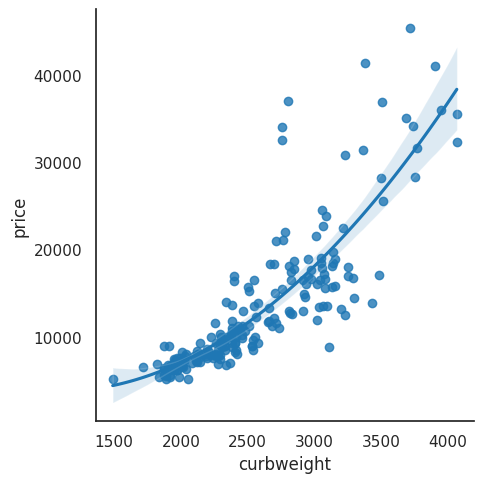

In [10]:
sns.lmplot(x = 'curbweight', y = 'price', data = data, order=2)

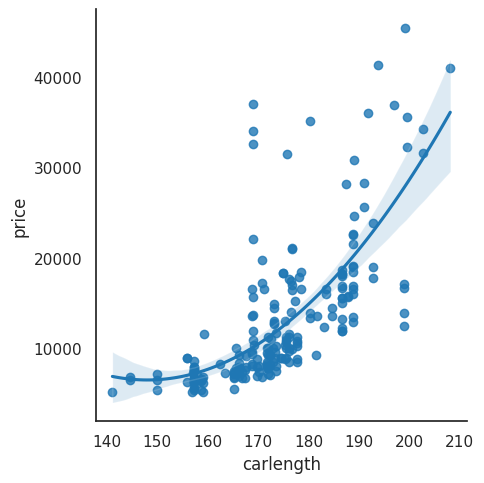

In [11]:
sns.lmplot(x = 'carlength', y = 'price', data = data, order=2)

The relationship is more curved.


## Exercise 1

In this Exercise, visualize the relationship between the 'horsepower' and the target variable, 'price'.


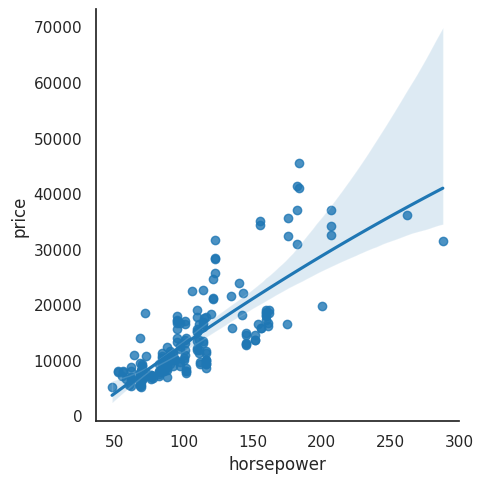

In [45]:
# Enter your code and run the cell
sns.lmplot(x = 'horsepower', y = 'price', data = data, order=2)

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>

sns.lmplot(x = 'horsepower', y = 'price', data = data, order=2)

</code>
</details>


## Data Preparation

Let's first split our data into `X` features and `y` target.


In [13]:
X = data.drop('price', axis=1)
y = data.price

## Train Test Split


Now that we have split our data into training and testing sets, the training data is used for your model to recognize patterns using some criteria,the test data set it used to evaluate your model, as shown in the following image:


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/images/trin-test.png">
</center>
<center>source scikit-learn.org</center>


Now, we split our data, using <code>train_test_split</code> function, into the training and testing sets, allocating 30% of the data for testing.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
print("Number of test samples:", X_test.shape[0])
print("Number of training samples:", X_train.shape[0])


Number of test samples: 62
Number of training samples: 143


### Multiple Features


Let's create a <code>LinearRegression</code> object, called `lm`.


In [15]:
lm = LinearRegression()

Now, let's fit the model with multiple features on our X_train and y_train data.


In [16]:
lm.fit(X_train, y_train)

LinearRegression()

We apply `predict(`) function on the testing data set.


In [17]:
predicted = lm.predict(X_test)

Let's calculate the `r2_score()` on both, training and testing data sets.


In [18]:
print("R^2 on training  data ",lm.score(X_train, y_train))
print("R^2 on testing data ",lm.score(X_test,y_test))

R^2 on training  data  0.9261062265101757
R^2 on testing data  0.8464742629904278


We can plot distributions of the predicted values versus the actual values.


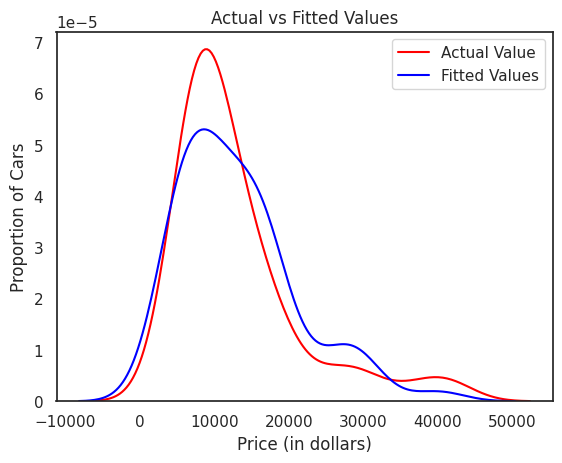

In [19]:
plot_dis(y_test,predicted)

Below, we will view the estimated coefficients for the linear regression problem.


In [20]:
{col:coef for col,coef in zip(X.columns, lm.coef_)}

{'diesel': -893483786668050.8,
 'gas': -893483786669703.1,
 'std': 317.45166015625,
 'turbo': -338.261474609375,
 'convertible': 1805.0232543945312,
 'hardtop': 3201.9473419189453,
 'hatchback': -1793.85107421875,
 'sedan': -677.6160888671875,
 'wagon': -2537.744171142578,
 '4wd': -594.0379028320312,
 'fwd': -264.3160400390625,
 'rwd': 858.5533447265625,
 'dohc': 2470.9165954589844,
 'dohcv': -13285.56704711914,
 'l': 2107.2716064453125,
 'ohc': 4639.123992919922,
 'ohcf': 6092.086761474609,
 'ohcv': -2804.906494140625,
 'rotor': 781.9382171630859,
 'eight': 9177.207901000977,
 'five': -2761.3700103759766,
 'four': -5313.635940551758,
 'six': -2145.7466430664062,
 'three': 0.001953125,
 'twelve': 261.8532028198242,
 'two': 781.9382171630859,
 'wheelbase': 106.638671875,
 'curbweight': 5.0,
 'enginesize': 23.47265625,
 'boreratio': -1793.3013305664062,
 'horsepower': 68.6796875,
 'carlength': -65.0859375,
 'carwidth': 581.9345703125,
 'citympg': -162.1640625,
 'highwaympg': 145.10546875

As we see, the first two coefficients are too large to plot, so we'll drop them and plot the rest of the coefficients.


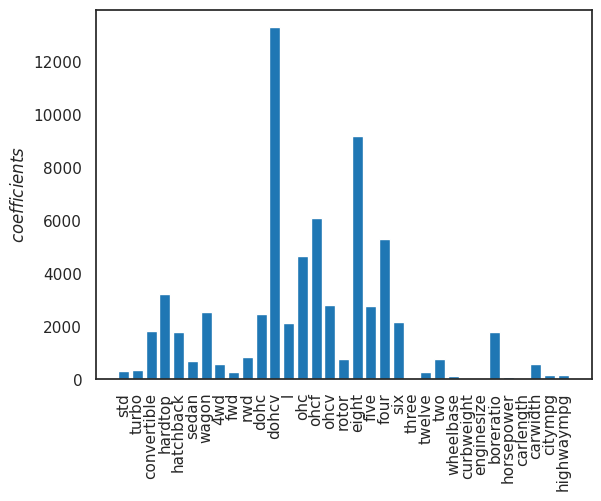

In [21]:
plt.bar(X.columns[2:],abs(lm.coef_[2:]))
plt.xticks(rotation=90)
plt.ylabel("$coefficients$")
plt.show()

Usually, we can interpret the lager coefficients as having more importance on the prediction, but this is not always the case, so let's look at the individual features.


### Individual Features


We can train the model and plot our $R^2$ for each of the features on the training and testing data sets, using the function <code>get_R2\_features</code>.


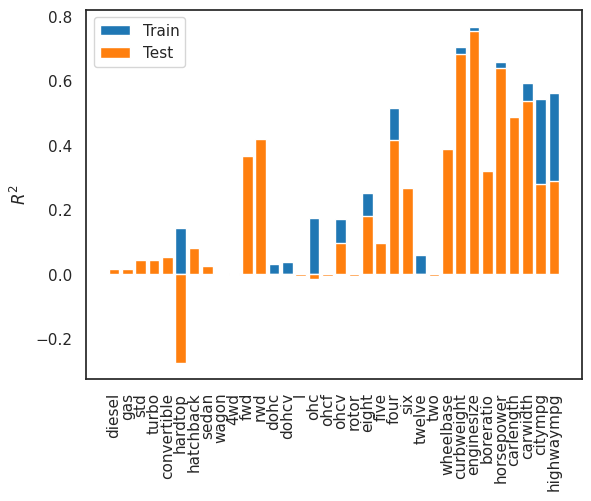

Training R^2 mean value 0.21817773426877918 Testing R^2 mean value 0.18241493035139267 
Training R^2 max value 0.7686929078033781 Testing R^2 max value 0.7534902447506853 


In [22]:
get_R2_features(lm)

From the above plot, we see that some individual features perform similarly to  using all the features (we removed the feature `three` ), in  addition, we see that smaller coefficients seem to correspond to a larger $R^{2}$, therefore  larger coefficients correspond to overfiting.


从你提供的输出和解释来看，以下是对结果的进一步分析和解释：

### **分析**：

1. **R² 平均值**：
   - **训练集的平均 R² 值**：0.218
   - **测试集的平均 R² 值**：0.182
   - 训练集和测试集的 R² 值差异较小，表明模型可能在训练集和测试集上都表现得相似，然而，整体的 R² 值并不高，这可能表明模型的预测能力较弱。

2. **R² 最大值**：
   - **训练集的最大 R² 值**：0.769
   - **测试集的最大 R² 值**：0.753
   - 最大 R² 值表明，对于某些特征，模型在训练集和测试集上都能较好地拟合数据。差距较小的最大值也暗示着模型可能并未在测试集上过拟合，尽管存在一些特征表现较好。

### **从图形观察到的结论**：
- **某些特征的表现与全特征模型相似**：根据你的描述，一些个别特征的表现与使用所有特征的模型（在去除 "three" 特征后）相似。这表明，有些特征在模型中可能包含了大量的信息，这些特征对模型的预测效果有重要贡献。
  
- **小系数与大系数的关系**：
  - **小系数对应较高的 R² 值**：小的系数可能意味着这些特征对目标变量的影响较小，模型更为简洁，可能会在测试集上表现得更好。这种情况通常与**更好的泛化能力**相关。
  - **大系数与过拟合**：较大的系数可能意味着模型过度拟合了训练数据中的噪声。过拟合通常会导致训练集上的高性能，但在测试集上却表现较差。通过观察图表中具有较大系数的特征，可以看到这些特征的 R² 值可能较高，但它们往往在测试集上的表现较差。

### **过拟合的原因和提示**：
- **过拟合通常会导致高训练集 R² 和低测试集 R²**。当模型在训练集上表现得非常好时，往往是因为它“记住”了训练数据中的细节和噪声，而不是学习到了一般化的模式。因此，在测试集上，它的表现较差。
  
- **为防止过拟合**，可以尝试以下几种方法：
  - **正则化**：使用 L1 或 L2 正则化来限制模型的复杂度。
  - **特征选择**：去除对预测贡献较小或与其他特征高度相关的特征。
  - **交叉验证**：使用交叉验证来评估模型的泛化能力。
  - **增加数据量**：如果可能，增加训练数据集的大小，有助于模型泛化。

### **总结**：
根据输出结果和图表，我们观察到一些特征在训练集和测试集上的表现差异较小，而其他特征则可能导致过拟合。通过进一步的正则化或特征选择，可以改善模型的泛化能力，从而减少过拟合，提高测试集上的预测能力。

如果你有进一步的问题或需要继续调整模型以减少过拟合，随时告诉我！

## Exercise 2

In this Exercise, calculate the $R^2$ using the object Pipeline for  Linear Regression and apply `StandardScaler()` to all features, then use the function `plot_dis` to compare the predicted values versus the actual values.


R^2 on training  data  0.9241368012938704
R^2 on testing data  -2.330830446863606e+22


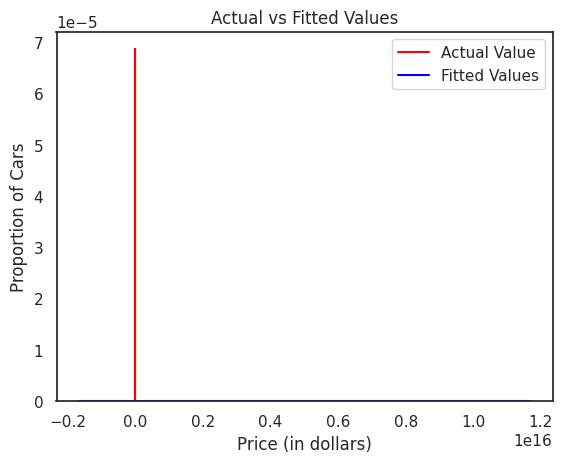

In [47]:
# Enter your code and run the cell
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
pipe.fit(X_train,y_train)
print("R^2 on training  data ", pipe.score(X_train, y_train))
print("R^2 on testing data ", pipe.score(X_test,y_test))
predicted = pipe.predict(X_test)
plot_dis(y_test,predicted)

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>

pipe = Pipeline(\[('ss',StandardScaler() ),('lr', LinearRegression())])
pipe.fit(X_train,y_train)
print("R^2 on training  data ", pipe.score(X_train, y_train))
print("R^2 on testing data ", pipe.score(X_test,y_test))
predicted = pipe.predict(X_test)
plot_dis(y_test,predicted)

</code>
</details>


## Exercise 3

In this Exercise, calculate the $R^2$ using the object Pipeline with  `StandardScaler()` for each individual features using the function `get_R2_features`.


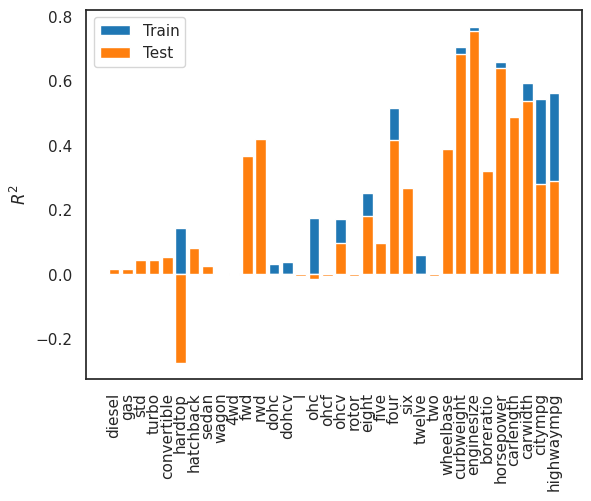

Training R^2 mean value 0.21817773426877918 Testing R^2 mean value 0.18241493035139264 
Training R^2 max value 0.7686929078033782 Testing R^2 max value 0.7534902447506853 


In [48]:
# Enter your code and run the cell
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
get_R2_features(pipe)

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; <code>

pipe = Pipeline(\[('ss',StandardScaler() ),('lr', LinearRegression())])
get_R2\_features(pipe)

</code>
</details>


## Polynomial Features


### Multiple Features


Polynomial transform is a simple way to increase the complexity of the model, but we must be mindful of overfilling.
Below, we will perform a second degree (degree=2) polynomial transformation.


In [25]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

Now, we transform the training and testing data sets.


In [26]:
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

`X_train_poly` and `X_test_poly` now contain the original features of X plus the square of these features and the cross-terms combination.
Let's check the shape of the newly created train and test sets.


In [27]:
print(X_train_poly.shape)


(143, 665)


In [28]:
print(X_test_poly.shape)

(62, 665)


Altogether, we have 665 features. Now, we fit the model with the newly created features.


In [29]:
lm = LinearRegression()
lm.fit(X_train_poly, y_train)

LinearRegression()

And we make predictions.


In [30]:
predicted = lm.predict(X_train_poly)

Again, we can ckeck the `r2_score()` on both, training and testing data sets.


In [31]:
print("R^2 on training data:", lm.score(X_train_poly, y_train))
print("R^2 on testing data:", lm.score(X_test_poly,y_test))

R^2 on training data: 0.9985318497975859
R^2 on testing data: -36729.95693460373


We see the model has a negative $R^{2}$ on the test data set, this is sign of overfiting.


### Individual Features


<p>Data Pipelines simplify the steps of processing the data. We use the module <code>Pipeline</code> to create a pipeline. We also use <code>PolynomialFeatures</code> as a step in our pipeline.</p>


In [32]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model', LinearRegression())]

We can repeat the steps above, using the <code>Pipleine</code> object.


In [33]:
pipe=Pipeline(Input)
pipe.fit(X_train, y_train)

Pipeline(steps=[('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

We can see the results are identical.


In [34]:
print("R^2 on training  data:", pipe.score(X_train, y_train))
print("R^2 on testing data:", pipe.score(X_test,y_test))

R^2 on training  data: 0.9985318497975859
R^2 on testing data: -36729.95693460373


We can train our model on each of the features using the Polynomial Feature transform of the second degree. Then we can plot our $R^2$.


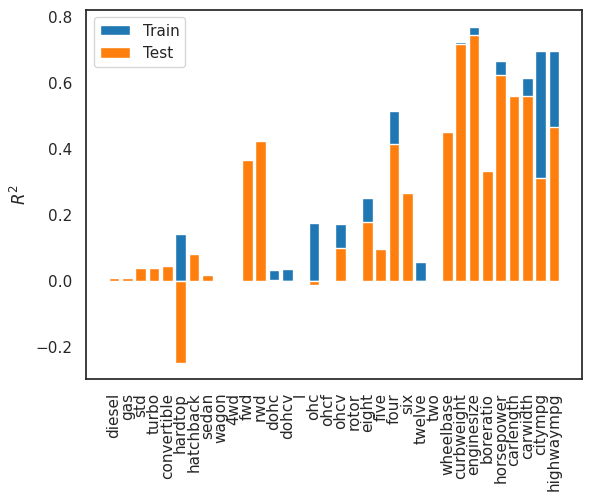

Training R^2 mean value 0.2305873848804811 Testing R^2 mean value 0.19372279912414778 
Training R^2 max value 0.7706959974452947 Testing R^2 max value 0.7463370080614308 


In [35]:
get_R2_features(pipe)

Feature with the max $R^{2}$ is higher than when using all the features.


## GridSearch and  Pipeline


In this section of the notebook, we will define a pipeline object, then use GridSearch to find the best hyper-parameters of the model by using  cross-validation method of the  parameter grid, as shown in the figure below. A 5-fold cross validation is used by default. We will learn more about k-fold cross validation in the next, Cross Validation lesson of the Course.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/images/k-fold.png">
</center>
<center>source scikit-learn.org</center>


We create `PolynomialFeatures()` pipeline.


In [36]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('scaler', StandardScaler()),('model',LinearRegression() )]
pipe=Pipeline(Input)

To search for the best combination of hyperparameters, we create a  <b>GridSearchCV</b> object with dictionary of parameter values. The parameters of pipelines can be set using the name of the key separated by
'\__', then the parameter name of the key.


In [37]:
param_grid = {
    "polynomial__degree": [1, 2, 3],
 
    
}

<b>polynomial\_\_degree</b>: is the degree of the polynomial.




In [38]:
search = GridSearchCV(pipe, param_grid, n_jobs=1)


In [39]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('polynomial', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [40]:
search.fit(X_test, y_test)

GridSearchCV(estimator=Pipeline(steps=[('polynomial',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('model', LinearRegression())]),
             n_jobs=1, param_grid={'polynomial__degree': [1, 2, 3]})

The object finds the best parameter values on the validation data. We can obtain the estimator with the best parameters and assign it to the variable `best`, as follows:


In [41]:
best=search.best_estimator_
best

Pipeline(steps=[('polynomial',
                 PolynomialFeatures(degree=1, include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

Now, we test our model on the test data to see the best score.


In [42]:
best.score(X_test,y_test)

0.9595416545417867

Finally, we can plot a distribution of the predicted values versus the actual values.


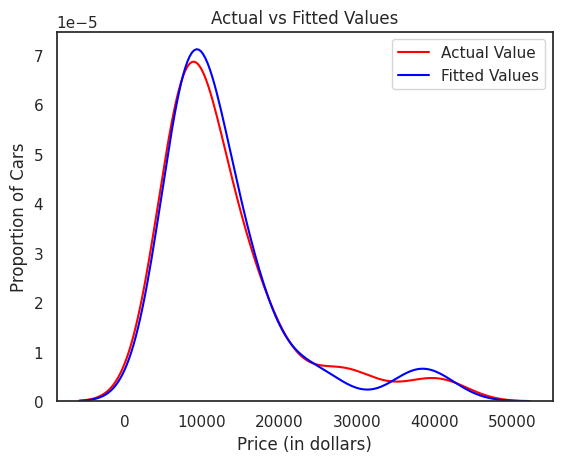

In [43]:
predicted=best.predict(X_test)
plot_dis(y_test,predicted)

As we see, the result is almost perfect!


## Exercise 4

In this Exercise, calculate the $R^2$ using the object `Pipeline` with `GridSearch` for each individual features.


diesel
gas
std
turbo
convertible
hardtop
hatchback
sedan
wagon
4wd
fwd
rwd
dohc
dohcv
l
ohc
ohcf
ohcv
rotor
eight
five
four
six
three
twelve
two
wheelbase
curbweight
enginesize
boreratio
horsepower
carlength
carwidth
citympg
highwaympg


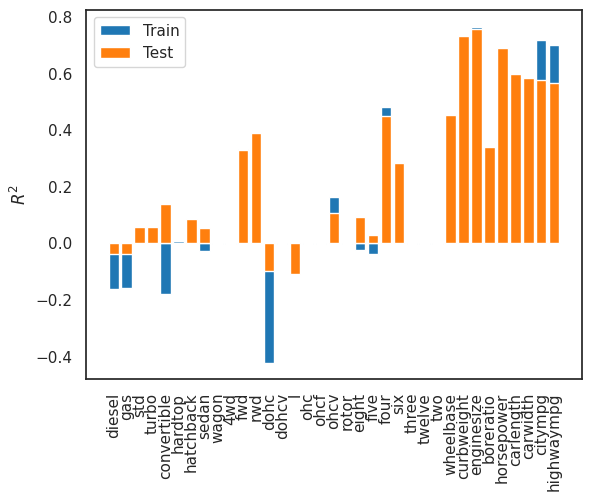

Training R^2 mean value 0.15324501452661068 Testing R^2 mean value 0.2025966100354837 
Training R^2 max value 0.765323637379124 Testing R^2 max value 0.7565151400968062 


In [49]:
# Enter your code and run the cell
features=list(X)


R_2_train=[]
R_2_test=[]

for feature in features:
    param_grid = {
    "polynomial__degree": [ 1, 2,3,4,5],
    "model__positive":[True, False]}
    Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model',LinearRegression())]
    pipe=Pipeline(Input)
    print(feature)
    search = GridSearchCV(pipe, param_grid, n_jobs=2)
    search.fit(X_test[[feature]], y_test)
    best=search.best_estimator_

    R_2_test.append(best.score(X_test[[feature]],y_test))
    R_2_train.append(best.score(X_train[[feature]],y_train))


plt.bar(features,R_2_train,label="Train")
plt.bar(features,R_2_test,label="Test")
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.legend()
plt.show()
print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )

<details>
<summary><strong>Solution</strong> (Click Here)</summary>
    &emsp; &emsp; 

```python
features=list(X)


R_2_train=[]
R_2_test=[]

for feature in features:
    param_grid = {
    "polynomial__degree": [ 1, 2,3,4,5],
    "model__positive":[True, False]}
    Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model',LinearRegression())]
    pipe=Pipeline(Input)
    print(feature)
    search = GridSearchCV(pipe, param_grid, n_jobs=2)
    search.fit(X_test[[feature]], y_test)
    best=search.best_estimator_

    R_2_test.append(best.score(X_test[[feature]],y_test))
    R_2_train.append(best.score(X_train[[feature]],y_train))


plt.bar(features,R_2_train,label="Train")
plt.bar(features,R_2_test,label="Test")
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.legend()
plt.show()
print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )
```

</details>


# Congratulations! - You have completed the lab


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>

[Svitlana Kramar](https://www.linkedin.com/in/svitlana-kramar?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01)


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By  | Change Description             |
| ----------------- | ------- | ----------- | ------------------------------ |
| 2022-04-18        | 0.1     | Joseph S.   | Updated all content            |
| 2022-04-26        | 0.1     | Svitlana K. | Corrected minor grammar errors |
